In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import geopandas as gpd
import shapely
import pandas as pd
from geodatasets import get_path
import ast
# import geopy.distances
from tqdm import tqdm

import matplotlib as mpl
from matplotlib.colors import ListedColormap
sys.path.append('../src/')
sys.path.append('../content/')
import data_utils as du
import vis_utils as vu
import sample_locations as sl
import loadpaths
path_dict_pecl = loadpaths.loadpaths()
# import shapely
# from tqdm import tqdm, tqdm_notebook
# import ast, shutil

In [ ]:
data_folder = '/Users/tplas/data/dw_sampled_locations/data_spherical/'
list_ids, modality_folders, gdf_points = du.get_list_complete_ids(data_folder)
print(f'Number of samples: {len(list_ids)}')

Sample random_sample has 9695 data points out of 18393.
Sample lc_stratified_sample has 9693 data points out of 18393.
Number of samples: 18393


            lat        lon
72888 -1.903417 -53.636346


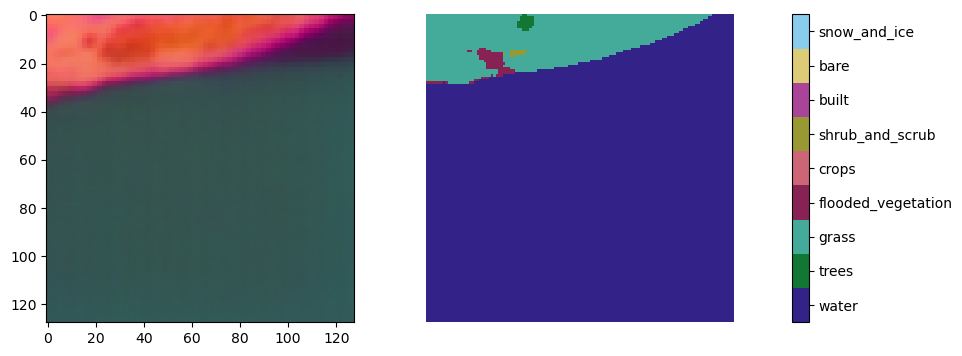

In [16]:
id = list_ids[13434]

ae = du.load_tiff(os.path.join(data_folder, 'alphaearth', f'{id}_alphaearth_y-2024.tif'), datatype='np')
dw = du.load_tiff(os.path.join(data_folder, 'dynamicworld', f'{id}_dynamicworld_y-2024.tif'), datatype='np')

fig, ax = plt.subplots(1, 3, figsize=(10, 4), gridspec_kw={'width_ratios': [1, 1, 0.05]})
vu.plot_dw_landcover_from_hyp(dw[:, :, :], ax=ax[1], cax=ax[2], fig=fig)
vu.plot_simple_overview_embeddings(ae, method='pca', bands=(3, 4, 5), ax=ax[0])

print(gdf_points[gdf_points.id == id][['lat', 'lon']])

## Extract centre only

In [17]:
patch_size = 128
AE_COLS = [f'ae_{i}' for i in range(ae.shape[0])]
cols = ['id','pix_x', 'pix_y', 'random_sample', 'lc_stratified_sample'] + du.DW_CLASSES + AE_COLS
results = {x: [] for x in cols}
x, y = 64, 64
for id in tqdm(list_ids[:]):
    ae = du.load_tiff(os.path.join(data_folder, 'alphaearth', f'{id}_alphaearth_y-2024.tif'), datatype='np')
    dw = du.load_tiff(os.path.join(data_folder, 'dynamicworld', f'{id}_dynamicworld_y-2024.tif'), datatype='np')
    bool_random = gdf_points[gdf_points.id == id]['random_sample'].values[0]
    bool_strat = gdf_points[gdf_points.id == id]['lc_stratified_sample'].values[0]
    
    dw_patch = dw[:, y, x]
    ae_patch = ae[:, y, x]
    results['id'].append(id)
    results['pix_x'].append(x)
    results['pix_y'].append(y)
    results['random_sample'].append(bool_random)
    results['lc_stratified_sample'].append(bool_strat)

    for j, c in enumerate(du.DW_CLASSES):
        results[c].append(dw_patch[j])
    for j in range(ae.shape[0]):
        results[f'ae_{j}'].append(ae_patch[j])

df_results_centre = pd.DataFrame(results)


100%|██████████| 18393/18393 [02:38<00:00, 116.23it/s]


In [ ]:
df_tmp = df_results_centre[df_results_centre.random_sample == True]
df_tmp = df_tmp[[c for c in df_tmp.columns if c.startswith('ae_')] + ['id']]
df_tmp.reset_index(drop=True, inplace=True)
df_tmp = df_tmp.rename(columns={c: c.replace('ae_', 'emb_') for c in df_tmp.columns if c.startswith('ae_')})
# df_tmp.to_csv(os.path.join(data_folder, 'random_sample_alphaearth_centre.csv'), index=False)

## Extract random pixels:


In [123]:
n_random_per_patch = 10 
patch_size = 128
AE_COLS = [f'ae_{i}' for i in range(ae.shape[0])]
cols = ['id','pix_x', 'pix_y', 'random_sample', 'lc_stratified_sample'] + du.DW_CLASSES + AE_COLS
results = {x: [] for x in cols}
for id in list_ids[:]:
    ae = du.load_tiff(os.path.join(data_folder, 'alphaearth', f'{id}_alphaearth_y-2024.tif'), datatype='np')
    dw = du.load_tiff(os.path.join(data_folder, 'dynamicworld', f'{id}_dynamicworld_y-2024.tif'), datatype='np')
    bool_random = gdf_points[gdf_points.id == id]['random_sample'].values[0]
    bool_strat = gdf_points[gdf_points.id == id]['lc_stratified_sample'].values[0]
    selected = set() 
    for i in range(n_random_per_patch):
        while True:
            x = np.random.randint(0, patch_size)
            y = np.random.randint(0, patch_size)
            if (x, y) not in selected:
                selected.add((x, y))
                break
        dw_patch = dw[:, y, x]
        ae_patch = ae[:, y, x]
        results['id'].append(id)
        results['pix_x'].append(x)
        results['pix_y'].append(y)
        results['random_sample'].append(bool_random)
        results['lc_stratified_sample'].append(bool_strat)

        for j, c in enumerate(du.DW_CLASSES):
            results[c].append(dw_patch[j])
        for j in range(ae.shape[0]):
            results[f'ae_{j}'].append(ae_patch[j])
        # results['ae_embedding'].append(np.squeeze(ae_patch))
df_results = pd.DataFrame(results)


In [151]:
df_results_geoclip_random = pd.read_csv('/Users/tplas/data/dw_sampled_locations/data_spherical/geoclip/random_sample_geoclip.csv')
df_results_geoclip_strat = pd.read_csv('/Users/tplas/data/dw_sampled_locations/data_spherical/geoclip/lc_stratified_sample_geoclip.csv')
GEOCLIP_COLS = [c for c in df_results_geoclip_random.columns if c.startswith('emb')]

In [158]:
df_results_satclip_random = pd.read_csv('/Users/tplas/data/dw_sampled_locations/data_spherical/satclip/random_sample_satclip.csv')
df_results_satclip_strat = pd.read_csv('/Users/tplas/data/dw_sampled_locations/data_spherical/satclip/lc_stratified_sample_satclip.csv')
SATCLIP_COLS = [c for c in df_results_satclip_random.columns if c.startswith('emb')]
SATCLIP_COLS

['emb_0',
 'emb_1',
 'emb_2',
 'emb_3',
 'emb_4',
 'emb_5',
 'emb_6',
 'emb_7',
 'emb_8',
 'emb_9',
 'emb_10',
 'emb_11',
 'emb_12',
 'emb_13',
 'emb_14',
 'emb_15',
 'emb_16',
 'emb_17',
 'emb_18',
 'emb_19',
 'emb_20',
 'emb_21',
 'emb_22',
 'emb_23',
 'emb_24',
 'emb_25',
 'emb_26',
 'emb_27',
 'emb_28',
 'emb_29',
 'emb_30',
 'emb_31',
 'emb_32',
 'emb_33',
 'emb_34',
 'emb_35',
 'emb_36',
 'emb_37',
 'emb_38',
 'emb_39',
 'emb_40',
 'emb_41',
 'emb_42',
 'emb_43',
 'emb_44',
 'emb_45',
 'emb_46',
 'emb_47',
 'emb_48',
 'emb_49',
 'emb_50',
 'emb_51',
 'emb_52',
 'emb_53',
 'emb_54',
 'emb_55',
 'emb_56',
 'emb_57',
 'emb_58',
 'emb_59',
 'emb_60',
 'emb_61',
 'emb_62',
 'emb_63',
 'emb_64',
 'emb_65',
 'emb_66',
 'emb_67',
 'emb_68',
 'emb_69',
 'emb_70',
 'emb_71',
 'emb_72',
 'emb_73',
 'emb_74',
 'emb_75',
 'emb_76',
 'emb_77',
 'emb_78',
 'emb_79',
 'emb_80',
 'emb_81',
 'emb_82',
 'emb_83',
 'emb_84',
 'emb_85',
 'emb_86',
 'emb_87',
 'emb_88',
 'emb_89',
 'emb_90',
 'emb_91'

20.35452050125148
19.405819212890567


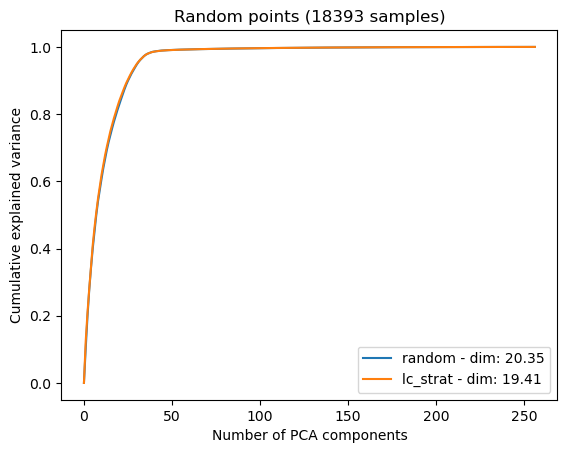

In [159]:
df_use = df_results_centre
import sklearn

# for name, df_sel in zip(['random_sample', 'lc_stratified_sample'], [df_use[df_use['random_sample'] == True], df_use[df_use['lc_stratified_sample'] == True]]):
# for name, df_sel in zip(['random', 'lc_strat'], [df_results_geoclip_random, df_results_geoclip_strat]):
for name, df_sel in zip(['random', 'lc_strat'], [df_results_satclip_random, df_results_satclip_strat]):
    # df_sel = df_results[df_results['lc_stratified_sample'] == True]
    pca = sklearn.decomposition.PCA(n_components=len(SATCLIP_COLS))
    ae_pca = pca.fit_transform(df_sel[SATCLIP_COLS].values)
    cum_expl_var = np.cumsum(pca.explained_variance_ratio_)
    sum_squares = np.sum(np.power(pca.explained_variance_, 2))
    square_sum = np.sum(pca.explained_variance_) ** 2
    dim = float(square_sum / sum_squares)

    print(dim)
    plt.plot([0] + list(cum_expl_var), label=f'{name} - dim: {dim:.2f}')
plt.xlabel('Number of PCA components')
plt.ylabel('Cumulative explained variance')
# plt.title(f'Centre-only ({len(df_use)} samples)')
plt.title(f'Random points ({len(df_use)} samples)')
plt.legend()

In [137]:
df_sel = df_results[df_results['lc_stratified_sample'] == True]
df_sel

,id,pix_x,pix_y,random_sample,lc_stratified_sample,water,trees,grass,flooded_vegetation,crops,...,ae_54,ae_55,ae_56,ae_57,ae_58,ae_59,ae_60,ae_61,ae_62,ae_63
10,14,121,81,0,1,0.264818,0.062574,0.057137,0.054892,0.036195,...,-0.002215,0.088827,-0.059116,-0.075356,0.048228,-0.035433,-0.228897,0.098424,-0.012057,0.119093
11,14,122,27,0,1,0.301837,0.057478,0.043237,0.046272,0.041006,...,-0.035433,0.108512,-0.032541,-0.032541,0.007443,-0.044844,-0.228897,0.071111,-0.035433,0.119093
12,14,64,40,0,1,0.328385,0.045994,0.033681,0.053506,0.034616,...,-0.048228,0.108512,-0.048228,-0.044844,0.019931,0.003937,-0.199862,0.103406,-0.038447,0.141730
13,14,74,41,0,1,0.354116,0.050581,0.032741,0.042019,0.031351,...,-0.032541,0.098424,-0.044844,-0.041584,0.017778,-0.059116,-0.214133,0.048228,0.003014,0.236463
14,14,126,37,0,1,0.042148,0.055789,0.207985,0.079835,0.038508,...,-0.035433,0.108512,-0.048228,-0.075356,0.038447,0.062991,-0.236463,0.147697,-0.079723,0.084214
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183925,99997,31,22,0,1,0.071467,0.075294,0.081461,0.102699,0.053738,...,0.027128,0.130165,0.079723,-0.079723,0.051734,-0.055363,-0.160000,0.035433,0.006151,0.141730
183926,99997,113,1,0,1,0.107595,0.146633,0.034198,0.054602,0.034493,...,0.051734,0.160000,0.098424,-0.093564,0.066990,-0.093564,-0.186082,0.062991,0.055363,0.160000
183927,99997,71,88,0,1,0.133323,0.096920,0.042236,0.071753,0.039334,...,0.019931,0.147697,0.108512,-0.051734,0.035433,-0.084214,-0.186082,0.017778,0.038447,0.179377
183928,99997,10,6,0,1,0.125590,0.066686,0.080593,0.064120,0.050956,...,0.010396,0.135886,0.084214,-0.027128,0.041584,-0.055363,-0.172795,0.027128,0.010396,0.124567


In [138]:
128 * 128

16384